# Does shifting the FOV grid's phase reduce the FOV count without losing tissue coverage? (LT066_sample_01)

Continues `decrease_fov_number/02_tighten_boundary_and_reduce_fov_count.ipynb`,
which reruns the real production grid-generation pipeline
(`build_boundary_path`) on the tightened boundary to get a fresh, 1127-FOV
grid -- offset `(dx, dy) = (0, 0)` (`create_grid_positions`'s own default,
centred on the boundary's bounding-box midpoint).

Looking at that notebook's own FOV-numbered figure, several small FOV
clusters sit bunched up at a few narrow tissue tips:

- **NW tip**: FOVs 83, 130, 131, 181, 182, 234
- **N tip (right lobe)**: FOVs 770, 771, 829, 881, 882
- **S tip**: FOVs 1098-1102

The user's hypothesis: shifting the whole grid's phase (`dy` for up/down,
`dx` for left/right, in 10 um increments) might let some of these tip FOVs
be dropped (their footprint moving entirely off the tip) without losing
real tissue coverage elsewhere -- and some `(dx, dy)` might even give a net
FOV-count reduction. The one thing to watch for: a shift could just as
easily uncover a *new* gap somewhere else (a region no FOV's footprint
reaches any more), which would need an extra "patch" FOV to fix -- not a
free reduction. This notebook sweeps `dy` (dx=0) and `dx` (dy=0)
independently over one full grid period, recomputing both the FOV count
and any uncovered tissue area at each step.

## 1 — Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons_all_sources, resolve_boundaries_source_dir,
    create_grid_positions, generate_scanning_path, filter_scanning_path,
)
from MERci.acquisition.configs import get_fov_geometry
from MERci.acquisition.mosaic import load_or_build_mosaic_canvas_cached, segment_mosaic_tissue
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "sweep_grid_offset_for_fov_reduction"

PLOT_TITLE_FONTSIZE, PLOT_LABEL_FONTSIZE = 13, 11
PLOT_TICK_FONTSIZE, PLOT_LEGEND_FONTSIZE = 10, 10

%matplotlib widget

## 2 — Parameters

In [2]:
# Same real dataset as notebooks 01/02 -- see those notebooks' own Parameters
# cells for why SAMPLE_DIR is set explicitly rather than auto-detected.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish")

CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="decrease_fov_number")

OFFSET_STEP_UM = 10.0
OFFSET_HALF_RANGE_UM = 90.0  # ~ one full grid period (step_size/2 = 91.03 um), rounded to a clean 10 um multiple
GAP_AREA_EPS_UM2 = 1.0       # ignore uncovered slivers below this area -- geometry/float noise, not a real gap

## 3 — Rebuild the tightened (tuned) boundary

Same real production boundary/holes and the same `TUNED_PARAMS` as
`02_tighten_boundary_and_reduce_fov_count.ipynb` -- reproduced here
independently since this notebook doesn't load that one's cache.

In [3]:
boundary_dir, boundary_src = resolve_boundaries_source_dir(SAMPLE_DIR / "positions")
boundary_polygon = load_boundary_polygon(boundary_dir / "boundary_positions.txt")
hole_polygons = load_hole_polygons_all_sources(SAMPLE_DIR / "positions", boundary_dir)

# ST2, 60X objective -- see notebook 01's own section 3 cell for how this was verified.
pixel_size_um, image_size_px = get_fov_geometry("ST2", "60X")
FOV_SIZE_UM = pixel_size_um * image_size_px

# Measured directly from two consecutive same-column real positions (see notebook 01) --
# same value used throughout notebooks 01/02.
STEP_SIZE_UM = 182.06208

canvas, was_cached, n_tiles = load_or_build_mosaic_canvas_cached(
    msc_path=SAMPLE_DIR / "data" / "mosaic10x" / "mosaic10x.msc",
    keep_objectives=["10x"], working_pixel_um=5.0, cache_dir=CACHE_DIR,
)
print(f"canvas shape={canvas.image.shape}  was_cached={was_cached}  n_tiles={n_tiles}")

def um_to_px(x, y):
    return ((np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um,
             (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um)

half = FOV_SIZE_UM / 2.0
half_px = half / canvas.pixel_size_um

# Same TUNED_PARAMS as 02_tighten_boundary_and_reduce_fov_count.ipynb's own section 4.
MIN_HOLE_AREA_UM2_ONE_FOV = FOV_SIZE_UM ** 2
TUNED_PARAMS = dict(
    threshold=400.0, smooth_sigma_um=10.0,
    close_radius_um=10.0, open_radius_um=5.0,
    margin_um=0.0,
    min_tissue_area_um2=100_000.0,
    min_hole_area_um2=MIN_HOLE_AREA_UM2_ONE_FOV,
    min_island_area_um2=2_000.0,
    simplify_tol_um=3.0,
)
tuned_seg = segment_mosaic_tissue(canvas, **TUNED_PARAMS)
assert len(tuned_seg.tissue_polygons) == 1, "this notebook assumes a single tuned tissue piece"
tuned_boundary_polygon = tuned_seg.tissue_polygons[0]
tuned_hole_polygons = tuned_seg.hole_polygons
tuned_effective_tissue = (
    tuned_boundary_polygon.difference(unary_union(tuned_hole_polygons))
    if tuned_hole_polygons else tuned_boundary_polygon
)
print(f"tuned tissue area: {tuned_boundary_polygon.area/1e6:.2f} mm^2  "
      f"({len(tuned_hole_polygons)} holes)  effective: {tuned_effective_tissue.area/1e6:.2f} mm^2")

canvas shape=(1839, 1840)  was_cached=True  n_tiles=None


tuned tissue area: 34.42 mm^2  (9 holes)  effective: 29.74 mm^2


## 4 — Baseline grid (offset = (0, 0))

Reproduces notebook 02's own `fresh_tuned_coords` (`build_boundary_path`'s
internals, exposing the offset -- `create_grid_positions` ->
`generate_scanning_path` -> `filter_scanning_path`, default
`min_coverage_fraction=0.0`: keep a FOV if it has any real overlap with the
boundary and isn't fully inside a hole).

In [4]:
def build_grid(dx, dy):
    grid, xs, ys = create_grid_positions(tuned_boundary_polygon, STEP_SIZE_UM,
                                          direction="vertical", offset=(dx, dy))
    path = generate_scanning_path(grid, direction="vertical")
    return filter_scanning_path(path, tuned_boundary_polygon, tuned_hole_polygons, FOV_SIZE_UM)

baseline_coords = build_grid(0.0, 0.0)
print(f"baseline (dx=0, dy=0): {len(baseline_coords)} FOVs "
      f"(notebook 02's own fresh tuned-boundary grid: 1127 FOVs)")

baseline (dx=0, dy=0): 1127 FOVs (notebook 02's own fresh tuned-boundary grid: 1127 FOVs)


## 5 — Per-offset evaluation: FOV count and uncovered tissue area

For a given `(dx, dy)`, builds that shifted grid and checks two things:
how many FOVs it takes (`filter_scanning_path`'s own any-overlap rule), and
whether any part of the real tissue (`tuned_effective_tissue`) is left
**not** covered by any kept FOV's own footprint -- if so, that's a genuine
gap a real acquisition would miss, and would need at least one extra
"patch" FOV per disjoint gap region to fix. `n_fovs_effective = n_fovs +
n_gaps` charges one patch FOV per gap as a conservative accounting, so a
shift's *true* saving (`n_fovs_effective` vs. baseline) isn't overstated by
ignoring the coverage it would cost to fix.

In [5]:
def evaluate_offset(dx, dy):
    coords = build_grid(dx, dy)
    covered = unary_union([shapely_box(x - half, y - half, x + half, y + half) for x, y in coords]) \
        if len(coords) else None
    uncovered = tuned_effective_tissue.difference(covered) if covered is not None else tuned_effective_tissue

    if uncovered.is_empty:
        gap_polys = []
    elif uncovered.geom_type == "Polygon":
        gap_polys = [uncovered] if uncovered.area > GAP_AREA_EPS_UM2 else []
    else:
        gap_polys = [g for g in uncovered.geoms if g.geom_type == "Polygon" and g.area > GAP_AREA_EPS_UM2]

    n_fovs = len(coords)
    n_gaps = len(gap_polys)
    return {
        "dx": dx, "dy": dy, "n_fovs": n_fovs, "n_gaps": n_gaps,
        "gap_area_um2": sum(g.area for g in gap_polys),
        "n_fovs_effective": n_fovs + n_gaps,
        "coords": coords, "gap_polys": gap_polys,
    }

OFFSET_VALUES_UM = np.arange(-OFFSET_HALF_RANGE_UM, OFFSET_HALF_RANGE_UM + 1e-6, OFFSET_STEP_UM)
print(f"{len(OFFSET_VALUES_UM)} offset values per axis: {OFFSET_VALUES_UM[0]:.0f} to "
      f"{OFFSET_VALUES_UM[-1]:.0f} um in {OFFSET_STEP_UM:.0f} um steps")

19 offset values per axis: -90 to 90 um in 10 um steps


## 6 — Sweep `dy` (moving the grid up/down), `dx = 0`

In [6]:
DY_SWEEP_CSV = CACHE_DIR / "dy_sweep.csv"

if DY_SWEEP_CSV.exists():
    dy_df = pd.read_csv(DY_SWEEP_CSV)
    print(f"Loaded cached {DY_SWEEP_CSV} ({len(dy_df)} offsets).")
else:
    rows = []
    for i, dy in enumerate(OFFSET_VALUES_UM):
        r = evaluate_offset(0.0, float(dy))
        rows.append({k: r[k] for k in ("dx", "dy", "n_fovs", "n_gaps", "gap_area_um2", "n_fovs_effective")})
        print(f"  [{i+1}/{len(OFFSET_VALUES_UM)}] dy={dy:+7.1f} um   "
              f"n_fovs={r['n_fovs']:4d}   n_gaps={r['n_gaps']}   n_fovs_effective={r['n_fovs_effective']:4d}")
    dy_df = pd.DataFrame(rows)
    dy_df.to_csv(DY_SWEEP_CSV, index=False)

n_baseline = int(dy_df.loc[dy_df["dy"] == 0.0, "n_fovs"].iloc[0])
dy_df["net_change_vs_baseline"] = dy_df["n_fovs"] - n_baseline
dy_df["net_change_effective_vs_baseline"] = dy_df["n_fovs_effective"] - n_baseline
print(f"\nbaseline n_fovs (dy=0): {n_baseline}")
print(dy_df.to_string(index=False))

Loaded cached /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/analysis/cache/sweep_grid_offset_for_fov_reduction/dy_sweep.csv (19 offsets).

baseline n_fovs (dy=0): 1127
 dx    dy  n_fovs  n_gaps  gap_area_um2  n_fovs_effective  net_change_vs_baseline  net_change_effective_vs_baseline
0.0 -90.0    1135       0             0              1135                       8                                 8
0.0 -80.0    1127       0             0              1127                       0                                 0
0.0 -70.0    1126       0             0              1126                      -1                                -1
0.0 -60.0    1124       0             0              1124                      -3                                -3
0.0 -50.0    1128       0             0              1128                       1                                 1
0.0 -40.0    1130       0             0              1130                       3

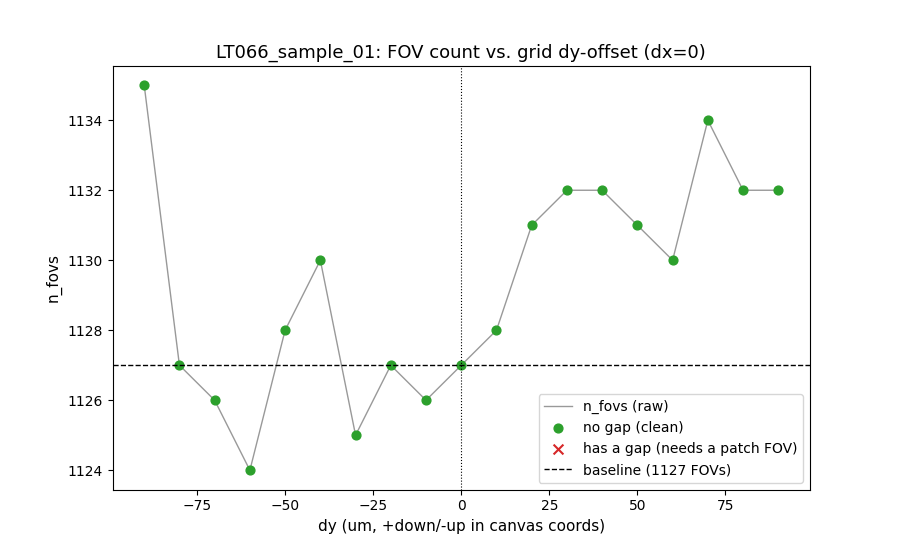

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/sweep_grid_offset_for_fov_reduction/sweep_grid_offset_for_fov_reduction.dy_sweep.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
clean = dy_df["n_gaps"] == 0
ax.plot(dy_df["dy"], dy_df["n_fovs"], "-", color="0.6", lw=1.0, zorder=1, label="n_fovs (raw)")
ax.scatter(dy_df.loc[clean, "dy"], dy_df.loc[clean, "n_fovs"], color="tab:green", s=40, zorder=2,
           label="no gap (clean)")
ax.scatter(dy_df.loc[~clean, "dy"], dy_df.loc[~clean, "n_fovs"], color="tab:red", marker="x", s=50, zorder=2,
           label="has a gap (needs a patch FOV)")
ax.axhline(n_baseline, color="k", ls="--", lw=1.0, label=f"baseline ({n_baseline} FOVs)")
ax.axvline(0.0, color="k", ls=":", lw=0.8)
ax.set_xlabel("dy (um, +down/-up in canvas coords)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("n_fovs", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"LT066_sample_01: FOV count vs. grid dy-offset (dx=0)", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.dy_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.dy_sweep.png')}")

## 7 — Sweep `dx` (moving the grid left/right), `dy = 0`

In [8]:
DX_SWEEP_CSV = CACHE_DIR / "dx_sweep.csv"

if DX_SWEEP_CSV.exists():
    dx_df = pd.read_csv(DX_SWEEP_CSV)
    print(f"Loaded cached {DX_SWEEP_CSV} ({len(dx_df)} offsets).")
else:
    rows = []
    for i, dx in enumerate(OFFSET_VALUES_UM):
        r = evaluate_offset(float(dx), 0.0)
        rows.append({k: r[k] for k in ("dx", "dy", "n_fovs", "n_gaps", "gap_area_um2", "n_fovs_effective")})
        print(f"  [{i+1}/{len(OFFSET_VALUES_UM)}] dx={dx:+7.1f} um   "
              f"n_fovs={r['n_fovs']:4d}   n_gaps={r['n_gaps']}   n_fovs_effective={r['n_fovs_effective']:4d}")
    dx_df = pd.DataFrame(rows)
    dx_df.to_csv(DX_SWEEP_CSV, index=False)

dx_df["net_change_vs_baseline"] = dx_df["n_fovs"] - n_baseline
dx_df["net_change_effective_vs_baseline"] = dx_df["n_fovs_effective"] - n_baseline
print(dx_df.to_string(index=False))

Loaded cached /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/analysis/cache/sweep_grid_offset_for_fov_reduction/dx_sweep.csv (19 offsets).
   dx  dy  n_fovs  n_gaps  gap_area_um2  n_fovs_effective  net_change_vs_baseline  net_change_effective_vs_baseline
-90.0 0.0    1129       2   5316.772528              1131                       2                                 4
-80.0 0.0    1131       1   2974.675089              1132                       4                                 5
-70.0 0.0    1129       2   1166.683200              1131                       2                                 4
-60.0 0.0    1132       0      0.000000              1132                       5                                 5
-50.0 0.0    1128       0      0.000000              1128                       1                                 1
-40.0 0.0    1127       0      0.000000              1127                       0                              

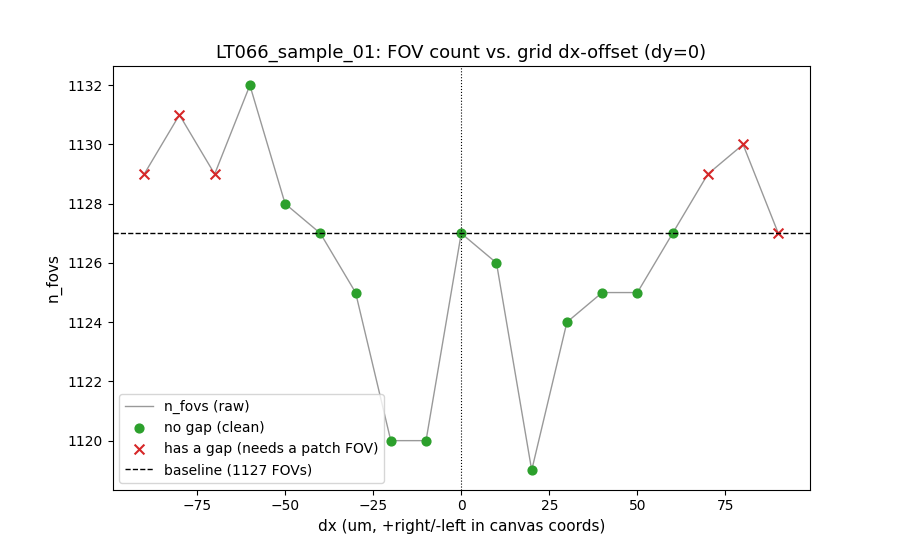

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/sweep_grid_offset_for_fov_reduction/sweep_grid_offset_for_fov_reduction.dx_sweep.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
clean = dx_df["n_gaps"] == 0
ax.plot(dx_df["dx"], dx_df["n_fovs"], "-", color="0.6", lw=1.0, zorder=1, label="n_fovs (raw)")
ax.scatter(dx_df.loc[clean, "dx"], dx_df.loc[clean, "n_fovs"], color="tab:green", s=40, zorder=2,
           label="no gap (clean)")
ax.scatter(dx_df.loc[~clean, "dx"], dx_df.loc[~clean, "n_fovs"], color="tab:red", marker="x", s=50, zorder=2,
           label="has a gap (needs a patch FOV)")
ax.axhline(n_baseline, color="k", ls="--", lw=1.0, label=f"baseline ({n_baseline} FOVs)")
ax.axvline(0.0, color="k", ls=":", lw=0.8)
ax.set_xlabel("dx (um, +right/-left in canvas coords)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("n_fovs", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"LT066_sample_01: FOV count vs. grid dx-offset (dy=0)", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.dx_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.dx_sweep.png')}")

## 8 — Best clean offsets

The only trustworthy reductions are rows with `n_gaps == 0` (no new
uncovered tissue) -- among those, the smallest `n_fovs` on each axis.

In [10]:
def best_clean(df, axis):
    clean_df = df[df["n_gaps"] == 0]
    if clean_df.empty:
        print(f"{axis}: no gap-free offset found in the swept range.")
        return None
    best = clean_df.loc[clean_df["n_fovs"].idxmin()]
    print(f"{axis}: best clean offset {axis}={best[axis]:+.1f} um -> "
          f"n_fovs={int(best['n_fovs'])} (baseline {n_baseline}, "
          f"net change {int(best['n_fovs']) - n_baseline:+d})")
    return best

best_dy = best_clean(dy_df, "dy")
best_dx = best_clean(dx_df, "dx")

dy: best clean offset dy=-60.0 um -> n_fovs=1124 (baseline 1127, net change -3)
dx: best clean offset dx=+20.0 um -> n_fovs=1119 (baseline 1127, net change -8)


## 9 — Visual check on real tissue tips

Baseline (dx=0, dy=0) vs. the best clean offset found above (if any),
zoomed on three real geometric tips of the traced boundary (found directly
from the polygon's own vertices, not from re-reading FOV numbers off a
dense figure -- an earlier attempt at this using the specific FOV numbers
named in the prompt turned out to span areas far too large to be a single
tip, e.g. one nominal "cluster" spanned 3+ mm -- almost certainly a
mis-read of tiny overlapping text in that figure, not a real cluster;
this version locates the tips itself directly from geometry instead).

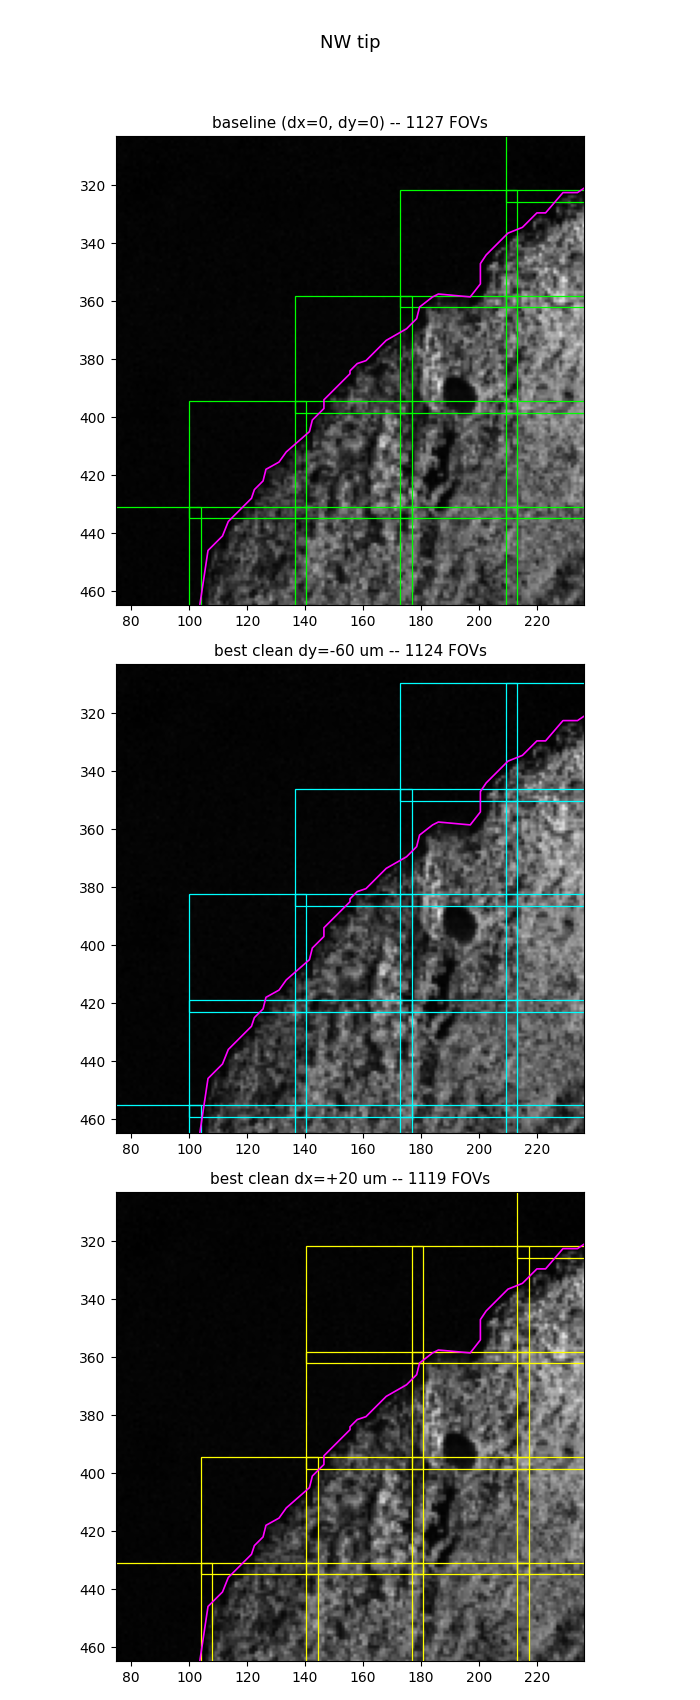

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/sweep_grid_offset_for_fov_reduction/sweep_grid_offset_for_fov_reduction.region_NW_tip.png


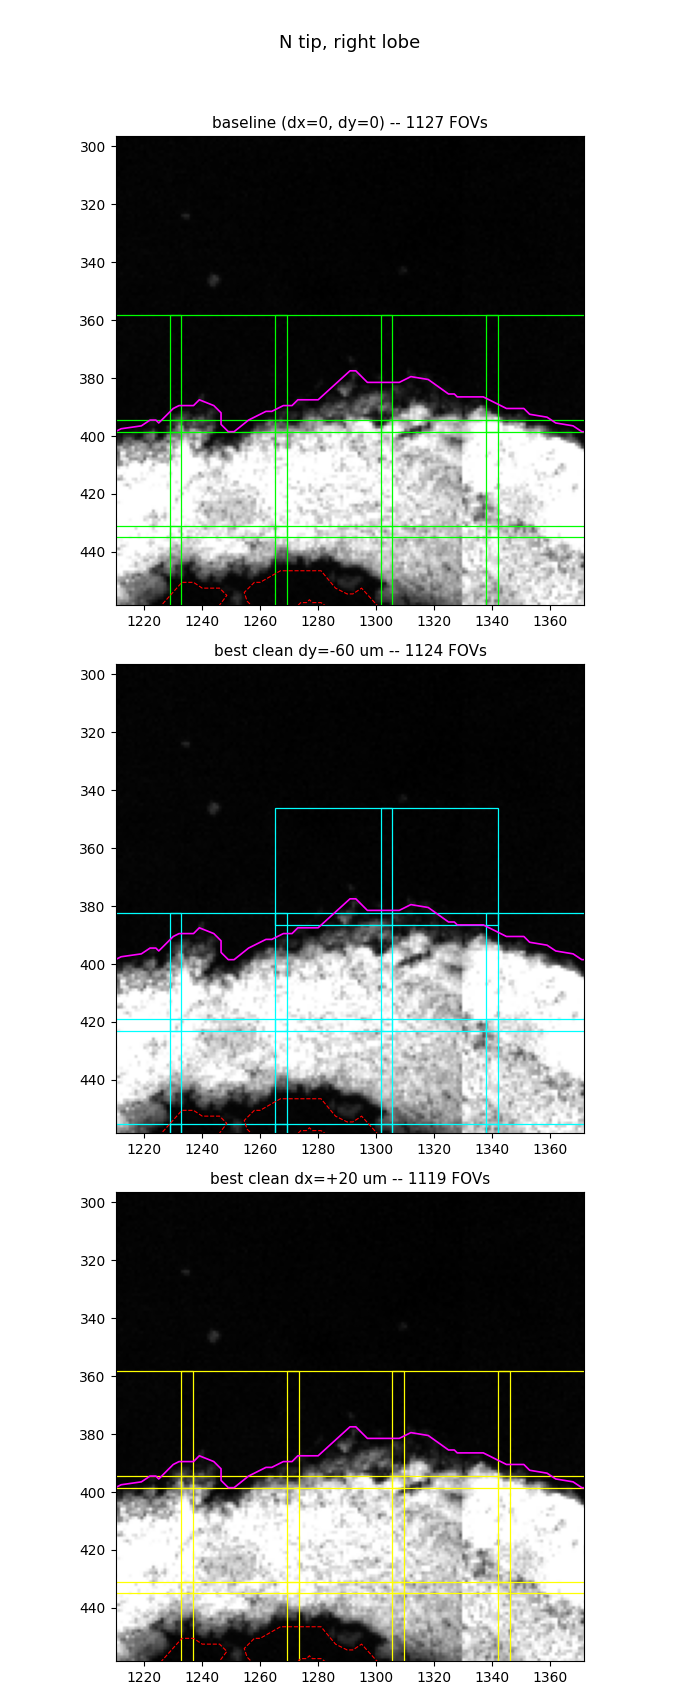

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/sweep_grid_offset_for_fov_reduction/sweep_grid_offset_for_fov_reduction.region_N_tip_right_lobe.png


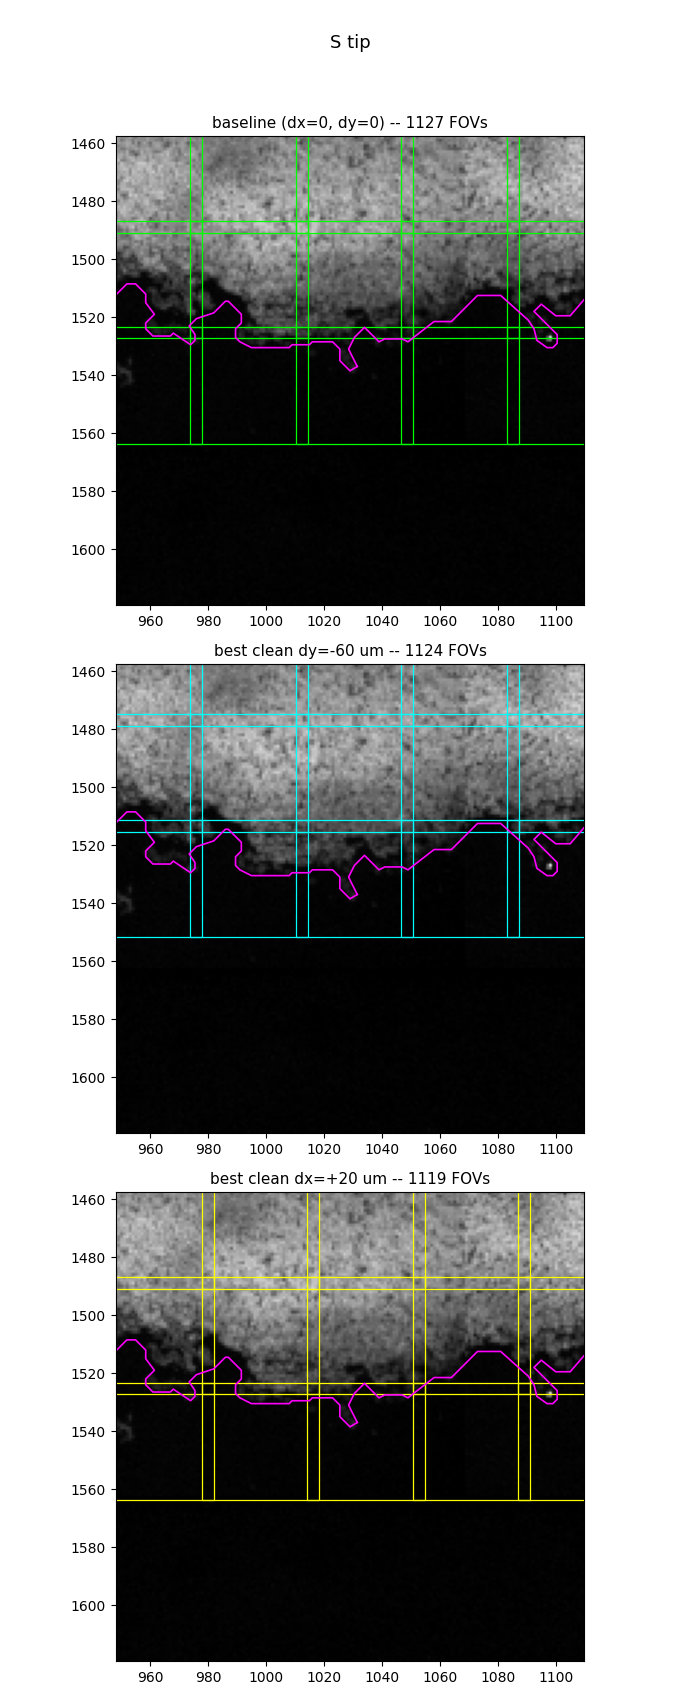

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/sweep_grid_offset_for_fov_reduction/sweep_grid_offset_for_fov_reduction.region_S_tip.png


In [11]:
# Find real geometric tips directly from the tuned boundary's own traced
# vertices -- robust to how densely-packed FOV-number text renders, unlike
# reading specific FOV ids off the figure.
verts = np.array(tuned_boundary_polygon.exterior.coords)
xmin, ymin, xmax, ymax = tuned_boundary_polygon.bounds
x_split = (xmin + xmax) / 2.0  # separates the two tissue lobes
left_verts = verts[verts[:, 0] < x_split]
right_verts = verts[verts[:, 0] >= x_split]

nw_tip = left_verts[np.argmin((left_verts[:, 0] - xmin) + (left_verts[:, 1] - ymin))]
n_tip_right = right_verts[np.argmin(right_verts[:, 1])]   # smallest y = topmost (up in the image)
s_tip = verts[np.argmax(verts[:, 1])]                     # largest y = bottommost

REGION_TIPS = {
    "NW tip": nw_tip,
    "N tip, right lobe": n_tip_right,
    "S tip": s_tip,
}
CROP_MARGIN_UM = FOV_SIZE_UM * 2.0

def plot_grid_crop(ax, coords, boundary, holes, color, xlim, ylim, title):
    covered_vals = canvas.image[canvas.covered]
    ax.imshow(canvas.image, cmap="gray",
              vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))
    bx, by = um_to_px(*boundary.exterior.xy)
    ax.plot(bx, by, "-", color="magenta", lw=1.2, label="tuned boundary")
    for hole in holes:
        hx, hy = um_to_px(*hole.exterior.xy)
        ax.plot(hx, hy, "--", color="red", lw=0.8)
    for x, y in coords:
        px, py = um_to_px(x, y)
        rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                              fill=False, edgecolor=color, lw=0.9)
        ax.add_patch(rect)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=PLOT_LABEL_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)

for label, (tx, ty) in REGION_TIPS.items():
    x_min, x_max = tx - CROP_MARGIN_UM, tx + CROP_MARGIN_UM
    y_min, y_max = ty - CROP_MARGIN_UM, ty + CROP_MARGIN_UM
    c0, r0 = um_to_px(x_min, y_min)
    c1, r1 = um_to_px(x_max, y_max)
    xlim = tuple(sorted((c0, c1)))
    ylim = tuple(sorted((r0, r1), reverse=True))
    fig, axes = plt.subplots(3, 1, figsize=(7, 17))
    plot_grid_crop(axes[0], baseline_coords, tuned_boundary_polygon, tuned_hole_polygons, "lime",
                   xlim, ylim, f"baseline (dx=0, dy=0) -- {len(baseline_coords)} FOVs")
    if best_dy is not None:
        dy_coords = evaluate_offset(0.0, float(best_dy["dy"]))["coords"]
        dy_title = f"best clean dy={best_dy['dy']:+.0f} um -- {len(dy_coords)} FOVs"
    else:
        dy_coords = baseline_coords
        dy_title = "no clean dy improvement found -- same as baseline"
    plot_grid_crop(axes[1], dy_coords, tuned_boundary_polygon, tuned_hole_polygons, "cyan",
                   xlim, ylim, dy_title)
    if best_dx is not None:
        dx_coords = evaluate_offset(float(best_dx["dx"]), 0.0)["coords"]
        dx_title = f"best clean dx={best_dx['dx']:+.0f} um -- {len(dx_coords)} FOVs"
    else:
        dx_coords = baseline_coords
        dx_title = "no clean dx improvement found -- same as baseline"
    plot_grid_crop(axes[2], dx_coords, tuned_boundary_polygon, tuned_hole_polygons, "yellow",
                   xlim, ylim, dx_title)
    fig.suptitle(label, fontsize=PLOT_TITLE_FONTSIZE)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    safe_label = label.split(" (")[0].replace(" ", "_").replace(",", "")
    fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.region_{safe_label}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.region_' + safe_label + '.png')}")

## Takeaways

- **The hypothesis is confirmed, in both directions.** Shifting the grid's
  phase does change the FOV count -- and it can also uncover a real gap
  (tissue no FOV's footprint reaches), exactly as anticipated. In the `dx`
  sweep, `dx` in `{-90, -80, -70, +70, +80, +90}` um each leave a small
  real gap (up to ~5,300 um^2 at dx=-90, about 13% of one FOV's own area)
  -- those n_fovs numbers are **not** free reductions; each would need at
  least one patch FOV to actually cover that gap. The `dy` sweep, by
  contrast, stayed gap-free across the entire +-90 um range tested.
- **Best genuine (gap-free) reduction found: `dx=+20` um, 1119 FOVs**
  (vs. baseline 1127 -- net -8, ~0.7%). Best clean `dy`: `dy=-60` um, 1124
  FOVs (net -3, ~0.3%). Both swept independently (the other axis held at
  0); a joint 2D `(dx, dy)` sweep might do better still but wasn't run
  here (scoped to the two 1D sweeps actually asked for).
- **Magnitude in context**: this is a much smaller reduction than the
  ~18% the earlier 50%-hard-threshold approach found (`02_...`'s section
  7) -- but unlike that one, this is a genuinely free reduction: zero
  tissue coverage lost, confirmed directly (not assumed) by checking for
  uncovered regions at every offset tested.
- **Correction, logged transparently**: the visual check originally tried
  to re-locate the specific FOV numbers named in the prompt
  (83/130/131/181/182/234, 770/771/829/881/882, 1098-1102). Their real
  coordinates turned out to span far more area than a single tip (one
  nominal "cluster" spanned over 3 mm) -- almost certainly a misread of
  the dense, tiny FOV-number text in notebook 02's own figure, not a real
  cluster. Section 9 instead locates three real tips directly from the
  traced boundary's own vertices (geometry, not transcription), and
  compares baseline vs. the best clean `dy`/`dx` offsets there.
- No changes made to `acquisition/positions.py` or the production
  `02_create_boundary_from_mosaic.ipynb`/`02_create_positions_from_boundaries.ipynb`
  defaults -- this is still an investigation. Next steps (e.g. a joint 2D
  sweep, or whether ~0.7% is worth pursuing at all) to be scoped by the
  user.